In [1]:
import os

os.environ["A3_API_KEY"] = "06654134"

if os.getenv("A3_API_KEY", "") == "":
    raise ValueError(
        "A3_API_KEY is not set. Please set it in your environment variables or use `os.environ['A3_API_KEY'] = 'your-8-digit-student-id'`"
    )

In [2]:
import time
import rich

from cs336_scaling.client import (
    get_budget,
    get_experiment,
    list_experiments,
    save_final_submission,
    submit_experiment,
)
from cs336_scaling.training.model.basic_model import BasicTransformerConfig
from cs336_scaling.training.optimizer import AdamWConfig, WarmupCosineDecay
from cs336_scaling.training.training_config import TrainingConfig

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from scipy.optimize import curve_fit

/Users/jackle/Documents/School/12_Spring_26/cs336/cs336-a3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
get_budget()

BudgetSummary(used_seconds=36391.46143442029, remaining_seconds=6808.538565579707, total_budget_seconds=43200.0)

In [90]:
def make_model(d, layers):
    inter = ((d * 8 // 3 + 63) // 64) * 64  # swiglu 8/3 * d, rounded up to multiple of 64
    n_params = 12 * layers * d ** 2
    
    return {"d": d, "heads": d // 64, "layers": layers, "inter": inter, "N": n_params}

In [ ]:
tokens_per_batch = 512 * 128
tokens = 300 * tokens_per_batch  # around 20M tokens, all models run for around 300 steps

In [201]:
models = {
    "1M": make_model(128, 5),
    "5M": make_model(256, 6),
    "15M": make_model(384, 8),
    "50M": make_model(512, 16),
}

In [ ]:
def submit_lr_experiments(experiment_ids, lrs):
    for m in models:
        for lr in lrs:
            config = TrainingConfig(
                architecture_config=BasicTransformerConfig(
                    attention_bias=False,
                    head_dim=64,
                    hidden_size=m["d"],
                    intermediate_size=m["inter"],
                    num_attention_heads=m["heads"],
                    num_hidden_layers=m["layers"],
                    num_key_value_heads=m["heads"],
                    rms_norm_eps=1e-6,
                    rope_theta=1_000_000,
                    tie_word_embeddings=False,
                    dtype="bfloat16",
                    vocab_size=32_000,
                ),
                optimizer_config=AdamWConfig(
                    lr_scheduler=WarmupCosineDecay(
                        peak_value=float(lr),
                        final_lr_frac=0.1,
                        warmup_frac=0.05,
                        init_value=0.0,
                    ),
                    weight_decay=1e-2,
                    beta1=0.9,
                    beta2=0.95,
                    eps=1e-8,
                    eps_root=1e-8,
                    grad_clip_norm=1.0,
                ),
                train_batch_size=128,
                val_batch_size=32,
                n_evals=10,
                total_train_tokens=tokens,
                max_runtime_seconds=120.0,
                model_seed=0,
            )
            try:
                result = submit_experiment(config)
                experiment_ids[(m["name"], float(lr))] = result.experiment_id
                print(f"Submitted {m['name']} lr={lr:.2e} -> id={result.experiment_id}")
            except Exception as e:
                print(f"Failed {m['name']} lr={lr:.2e}: {e}")

    print(f"Submitted {len(experiment_ids)} experiments")
    print(get_budget())

In [8]:
experiment_ids = {}
submit_lr_experiments(experiment_ids, [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2])

Submitted 1M lr=1.00e-04 -> id=4278
Submitted 1M lr=3.00e-04 -> id=4279
Submitted 1M lr=1.00e-03 -> id=4280
Submitted 1M lr=3.00e-03 -> id=4281
Submitted 1M lr=1.00e-02 -> id=4282
Submitted 1M lr=3.00e-02 -> id=4283
Submitted 5M lr=1.00e-04 -> id=4284
Submitted 5M lr=3.00e-04 -> id=4285
Submitted 5M lr=1.00e-03 -> id=4286
Submitted 5M lr=3.00e-03 -> id=4287
Submitted 5M lr=1.00e-02 -> id=4288
Submitted 5M lr=3.00e-02 -> id=4289
Submitted 15M lr=1.00e-04 -> id=4290
Submitted 15M lr=3.00e-04 -> id=4291
Submitted 15M lr=1.00e-03 -> id=4292
Submitted 15M lr=3.00e-03 -> id=4293
Submitted 15M lr=1.00e-02 -> id=4294
Submitted 15M lr=3.00e-02 -> id=4295
Submitted 50M lr=1.00e-04 -> id=4296
Submitted 50M lr=3.00e-04 -> id=4297
Submitted 50M lr=1.00e-03 -> id=4298
Submitted 50M lr=3.00e-03 -> id=4299
Submitted 50M lr=1.00e-02 -> id=4300
Submitted 50M lr=3.00e-02 -> id=4301
Submitted 24 experiments
used_seconds=39271.46143442029 remaining_seconds=3928.538565579707 total_budget_seconds=43200.0


In [18]:
submit_lr_experiments(experiment_ids, [5e-3, 5e-2])

Submitted 1M lr=5.00e-03 -> id=4307
Submitted 1M lr=5.00e-02 -> id=4308
Submitted 5M lr=5.00e-03 -> id=4309
Submitted 5M lr=5.00e-02 -> id=4310
Submitted 15M lr=5.00e-03 -> id=4311
Submitted 15M lr=5.00e-02 -> id=4312
Submitted 50M lr=5.00e-03 -> id=4313
Submitted 50M lr=5.00e-02 -> id=4314
Submitted 32 experiments
used_seconds=37860.351205070205 remaining_seconds=5339.648794929795 total_budget_seconds=43200.0


In [25]:
submit_lr_experiments(experiment_ids, [2e-3])

Submitted 1M lr=2.00e-03 -> id=4319
Submitted 5M lr=2.00e-03 -> id=4320
Submitted 15M lr=2.00e-03 -> id=4321
Submitted 50M lr=2.00e-03 -> id=4322
Submitted 36 experiments
used_seconds=37542.69185809535 remaining_seconds=5657.30814190465 total_budget_seconds=43200.0


In [103]:
def round_to_nearest(buckets, value):
    return min(buckets, key=lambda x: abs(value - x))

In [203]:
lr_experiments = [e for e in list_experiments() if e.training_config.total_train_tokens == tokens]

results = []
for exp in lr_experiments:
    if exp.status.status_type == "completed":
        cfg = exp.training_config.architecture_config
        N = 12 * cfg.num_hidden_layers * cfg.hidden_size ** 2
        lr = exp.training_config.optimizer_config.lr_scheduler.peak_value
        loss = exp.status.val_losses[-1]
        n_params = round_to_nearest([1e6, 5e6, 15e6, 50e6], N)
        result = {"model": f"{int(n_params//1e6)}M", "lr": lr, "loss": loss}
        results.append(result)
        
print(len(lr_experiments))

37


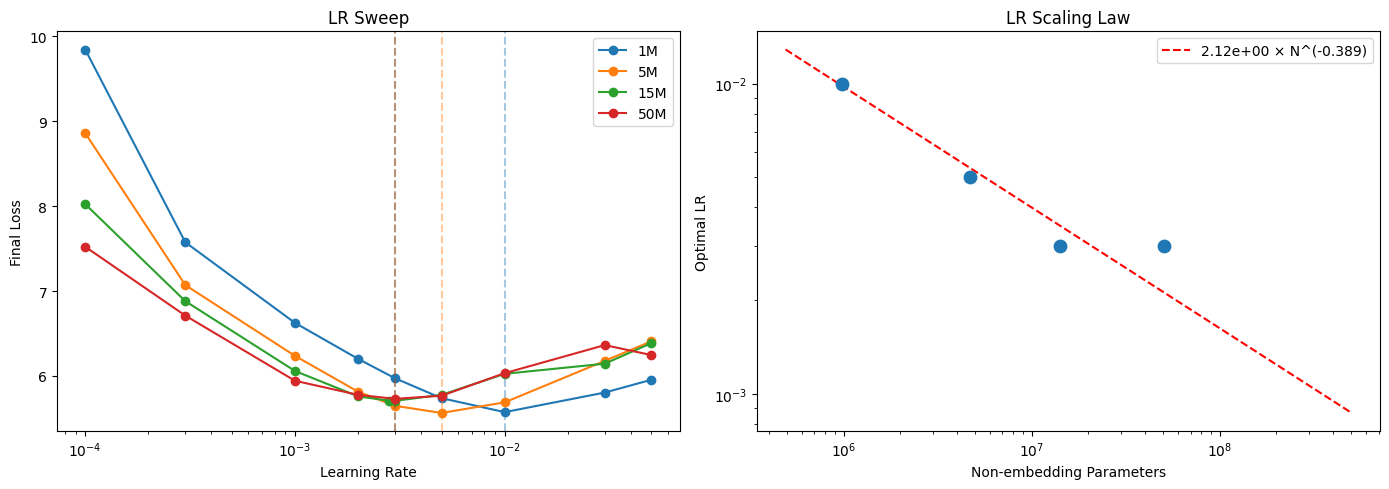

lr_opt = 2.1166e+00 * N^(-0.3893)


In [205]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = {"1M": "C0", "5M": "C1", "15M": "C2", "50M": "C3"}
best_lrs = {}
for name in models.keys():
    runs = sorted([r for r in results if r["model"] == name], key=lambda r: r["lr"])
    ax1.plot([r["lr"] for r in runs], [r["loss"] for r in runs], "o-",
             color=colors[name], label=name)
    best = min(runs, key=lambda r: r["loss"])
    best_lrs[name] = best["lr"]
    ax1.axvline(best["lr"], color=colors[name], linestyle="--", alpha=0.4)

ax1.set_xscale("log")
ax1.set_xlabel("Learning Rate")
ax1.set_ylabel("Final Loss")
ax1.set_title("LR Sweep")
ax1.legend()

Ns = np.array([models[n]['N'] for n in best_lrs])
lr_opts = np.array([best_lrs[n] for n in best_lrs])
popt, _ = curve_fit(lambda N, a, b: a * N**b, Ns, lr_opts, p0=[1.0, -0.1])
a, b = popt

N_fit = np.logspace(np.log10(Ns.min() / 2), np.log10(Ns.max() * 10), 100)
ax2.scatter(Ns, lr_opts, s=80, zorder=5)
ax2.plot(N_fit, a * N_fit**b, "r--", label=f"{a:.2e} × N^({b:.3f})")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Non-embedding Parameters")
ax2.set_ylabel("Optimal LR")
ax2.set_title("LR Scaling Law")
ax2.legend()

plt.tight_layout()
plt.savefig("writeup/figures/lr_scaling.png")
plt.show()
print(f"lr_opt = {a:.4e} * N^({b:.4f})")

# Begin Isoflop experiments

In [206]:
def get_lr_opt(N):
    return min(max(2.1166 * N**(-0.3893), 1e-4), 0.03)

In [135]:
models = [
    make_model(192, 6),  # 2.65M
    make_model(256, 6),  # 4.72M
    make_model(384, 6),  # 10.6M
    make_model(384, 14),  # 24.8M
    make_model(512, 12),  # 37.7M
    make_model(768, 8),  # 56.6M
]

for m in models:
    lr_opt = get_lr_opt(m["N"])

    print(f"N={m["N"]/1e6:.2f}M lr_opt={lr_opt:.2e} {m}")

    m["lr_opt"] = lr_opt

N=2.65M lr_opt=6.68e-03 {'d': 192, 'heads': 3, 'layers': 6, 'inter': 512, 'N': 2654208}
N=4.72M lr_opt=5.34e-03 {'d': 256, 'heads': 4, 'layers': 6, 'inter': 704, 'N': 4718592}
N=10.62M lr_opt=3.89e-03 {'d': 384, 'heads': 6, 'layers': 6, 'inter': 1024, 'N': 10616832}
N=24.77M lr_opt=2.80e-03 {'d': 384, 'heads': 6, 'layers': 14, 'inter': 1024, 'N': 24772608}
N=37.75M lr_opt=2.38e-03 {'d': 512, 'heads': 8, 'layers': 12, 'inter': 1408, 'N': 37748736}
N=56.62M lr_opt=2.03e-03 {'d': 768, 'heads': 12, 'layers': 8, 'inter': 2048, 'N': 56623104}


In [208]:
def submit_isoflop_experiments(experiment_ids, compute_budgets, max_runtime=180.0):
    for C in compute_budgets:
        for m in models:
            n_evals = 10
            step_chunk = n_evals * tokens_per_batch  # must be divisible by this

            D = int(C / (6 * m["N"]) // step_chunk) * step_chunk

            config = TrainingConfig(
                architecture_config=BasicTransformerConfig(
                    attention_bias=False,
                    head_dim=64,
                    hidden_size=m["d"],
                    intermediate_size=m["inter"],
                    num_attention_heads=m["heads"],
                    num_hidden_layers=m["layers"],
                    num_key_value_heads=m["heads"],
                    rms_norm_eps=1e-6,
                    rope_theta=1_000_000,
                    tie_word_embeddings=False,
                    dtype="bfloat16",
                    vocab_size=32_000,
                ),
                optimizer_config=AdamWConfig(
                    lr_scheduler=WarmupCosineDecay(
                        peak_value=m["lr_opt"],
                        final_lr_frac=0.1,
                        warmup_frac=0.05,
                        init_value=0.0,
                    ),
                    weight_decay=1e-2,
                    beta1=0.9,
                    beta2=0.95,
                    eps=1e-8,
                    eps_root=1e-8,
                    grad_clip_norm=1.0,
                ),
                train_batch_size=128,
                val_batch_size=32,
                n_evals=10,
                total_train_tokens=D,
                max_runtime_seconds=max_runtime,
                model_seed=0,
            )
            try:
                result = submit_experiment(config)
                experiment_ids[(C, m["N"])] = result.experiment_id
                print(
                    f"C={C:.0e} N={m['N']/1e6:.2f}M D={D/1e6:.1f}M lr={m['lr_opt']:.2e} -> id={result.experiment_id}"
                )
            except Exception as e:
                print(f"C={C:.0e} N={m['N']/1e6:.2f}M -> FAILED: {e}")

    print(f"\n{len(experiment_ids)} submitted")
    print(get_budget())

In [141]:
compute_budgets = [3e14]

experiment_ids = {}
submit_isoflop_experiments(experiment_ids, compute_budgets)

C=3e+14 N=2.65M D=18.4M lr=6.68e-03 -> id=4345
C=3e+14 N=4.72M D=10.5M lr=5.34e-03 -> id=4346
C=3e+14 N=10.62M D=4.6M lr=3.89e-03 -> id=4347
C=3e+14 N=24.77M D=2.0M lr=2.80e-03 -> id=4348
C=3e+14 N=37.75M D=1.3M lr=2.38e-03 -> id=4349
C=3e+14 N=56.62M D=0.7M lr=2.03e-03 -> id=4350

6 submitted
used_seconds=38229.53767243633 remaining_seconds=4970.4623275636695 total_budget_seconds=43200.0


In [142]:
compute_budgets = [1e15, 3e15, 1e16]
submit_isoflop_experiments(experiment_ids, compute_budgets)

C=1e+15 N=2.65M D=62.3M lr=6.68e-03 -> id=4351
C=1e+15 N=4.72M D=34.7M lr=5.34e-03 -> id=4352
C=1e+15 N=10.62M D=15.1M lr=3.89e-03 -> id=4353
C=1e+15 N=24.77M D=6.6M lr=2.80e-03 -> id=4354
C=1e+15 N=37.75M D=3.9M lr=2.38e-03 -> id=4355
C=1e+15 N=56.62M D=2.6M lr=2.03e-03 -> id=4356
C=3e+15 N=2.65M D=188.1M lr=6.68e-03 -> id=4357
C=3e+15 N=4.72M D=105.5M lr=5.34e-03 -> id=4358
C=3e+15 N=10.62M D=46.5M lr=3.89e-03 -> id=4359
C=3e+15 N=24.77M D=19.7M lr=2.80e-03 -> id=4360
C=3e+15 N=37.75M D=13.1M lr=2.38e-03 -> id=4361
C=3e+15 N=56.62M D=8.5M lr=2.03e-03 -> id=4362
C=1e+16 N=2.65M D=627.8M lr=6.68e-03 -> id=4363
C=1e+16 N=4.72M D=352.6M lr=5.34e-03 -> id=4364
C=1e+16 N=10.62M D=156.6M lr=3.89e-03 -> id=4365
C=1e+16 N=24.77M D=66.8M lr=2.80e-03 -> id=4366
C=1e+16 N=37.75M D=43.9M lr=2.38e-03 -> id=4367
C=1e+16 N=56.62M D=28.8M lr=2.03e-03 -> id=4368

24 submitted
used_seconds=40420.97455147106 remaining_seconds=2779.0254485289406 total_budget_seconds=43200.0


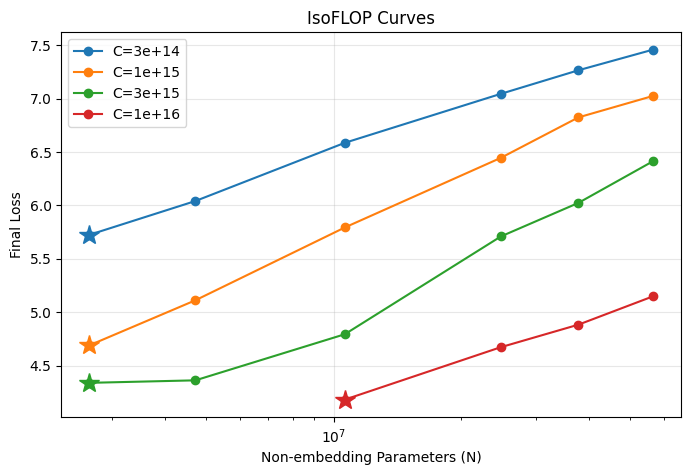

In [154]:
results = []
for (C, N), eid in experiment_ids.items():
    exp = get_experiment(eid)
    if exp.status.status_type == "completed":
        results.append({"C": C, "N": N, "loss": exp.status.val_losses[-1]})

budgets = sorted(set(r["C"] for r in results))

fig, ax = plt.subplots(figsize=(8, 5))

best_N, best_D = {}, {}
for i, C in enumerate(budgets):
    pts = sorted([r for r in results if r["C"] == C], key=lambda r: r["N"])
    ax.plot([r["N"] for r in pts], [r["loss"] for r in pts], "o-", color=f"C{i}", label=f"C={C:.0e}")
    best = min(pts, key=lambda r: r["loss"])
    best_N[C] = best["N"]
    best_D[C] = C / (6 * best["N"])
    ax.plot(best["N"], best["loss"], "*", color=f"C{i}", ms=15)

ax.set_xscale("log")
ax.set_xlabel("Non-embedding Parameters (N)")
ax.set_ylabel("Final Loss")
ax.set_title("IsoFLOP Curves")
ax.legend()
ax.grid(True, alpha=0.3)

In [153]:
models = [
    make_model(64, 4),  # 0.20M
    make_model(64, 8),  # 0.39M
    make_model(128, 3),  # 0.59M
    make_model(128, 6),  # 1.18M
]

for m in models:
    lr_opt = get_lr_opt(m["N"])
    m["lr_opt"] = lr_opt

compute_budgets = [3e14, 1e15, 3e15]
submit_isoflop_experiments(experiment_ids, compute_budgets)

C=3e+14 N=0.20M D=254.3M lr=1.84e-02 -> id=4377
C=3e+14 N=0.39M D=127.1M lr=1.40e-02 -> id=4378
C=3e+14 N=0.59M D=84.5M lr=1.20e-02 -> id=4379
C=3e+14 N=1.18M D=41.9M lr=9.16e-03 -> id=4380
C=1e+15 N=0.20M D=847.4M lr=1.84e-02 -> id=4381
C=1e+15 N=0.39M D=423.4M lr=1.40e-02 -> id=4382
C=1e+15 N=0.59M D=282.5M lr=1.20e-02 -> id=4383
C=1e+15 N=1.18M D=140.9M lr=9.16e-03 -> id=4384
C=3e+15 N=0.20M D=2542.8M lr=1.84e-02 -> id=4385
C=3e+15 N=0.39M D=1271.4M lr=1.40e-02 -> id=4386
C=3e+15 N=0.59M D=847.4M lr=1.20e-02 -> id=4387
C=3e+15 N=1.18M D=423.4M lr=9.16e-03 -> id=4388

36 submitted
used_seconds=40425.27434492318 remaining_seconds=2774.7256550768216 total_budget_seconds=43200.0


In [159]:
compute_budgets = [1e14]
submit_isoflop_experiments(experiment_ids, compute_budgets)

C=1e+14 N=0.20M D=84.5M lr=1.84e-02 -> id=4389
C=1e+14 N=0.39M D=41.9M lr=1.40e-02 -> id=4390
C=1e+14 N=0.59M D=28.2M lr=1.20e-02 -> id=4391
C=1e+14 N=1.18M D=13.8M lr=9.16e-03 -> id=4392

40 submitted
used_seconds=40571.65267207982 remaining_seconds=2628.347327920179 total_budget_seconds=43200.0


In [309]:
models = [
    make_model(192, 6),  # 2.65M
    make_model(256, 6),  # 4.72M
    make_model(384, 6),  # 10.6M
    make_model(384, 14),  # 24.8M
]
for m in models:
    lr_opt = get_lr_opt(m["N"])
    m["lr_opt"] = lr_opt

compute_budgets = [1e14]
submit_isoflop_experiments(experiment_ids, compute_budgets)

C=1e+14 N=2.65M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":43199.65692392757,"remaining_seconds":0.34307607242953964,"total_budget_seconds":43200.0}}}
C=1e+14 N=4.72M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":43199.65692392757,"remaining_seconds":0.34307607242953964,"total_budget_seconds":43200.0}}}
C=1e+14 N=10.62M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":43199.65692392757,"remaining_seconds":0.34307607242953964,"total_budget_seconds":43200.0}}}
C=1e+14 N=24.77M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_sum

In [236]:
models = [
    make_model(128, 6),  # 1.18M
    make_model(192, 6),  # 2.65M
    make_model(256, 6),  # 4.72M
    make_model(384, 6),  # 10.6M
]
for m in models:
    lr_opt = get_lr_opt(m["N"])
    m["lr_opt"] = lr_opt

compute_budgets = [1e16]
submit_isoflop_experiments(experiment_ids, compute_budgets, max_runtime=600)

C=1e+16 N=1.18M D=1412.3M lr=9.16e-03 -> id=4429
C=1e+16 N=2.65M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":43133.53694157058,"remaining_seconds":66.46305842942093,"total_budget_seconds":43200.0}}}
C=1e+16 N=4.72M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":43133.53694157058,"remaining_seconds":66.46305842942093,"total_budget_seconds":43200.0}}}
C=1e+16 N=10.62M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":43133.53694157058,"remaining_seconds":66.46305842942093,"total_budget_seconds":43200.0}}}

51 submitted
used_seconds=43133.53694157058 remaining_seconds=66.46305842942093 total_budget_seconds=43200.0


In [295]:
models = [
    make_model(256, 6),  # 4.72M
    make_model(384, 6),  # 10.6M
    make_model(384, 14),  # 24.8M
    make_model(512, 12),  # 37.7M
    make_model(768, 8),  # 56.6M
    make_model(1024, 8),  # 100.7M
    make_model(1280, 10),  # 196.6M
]

for m in models:
    lr_opt = get_lr_opt(m["N"])
    m["lr_opt"] = lr_opt
    print(m)

compute_budgets = [3e16]
submit_isoflop_experiments(experiment_ids, compute_budgets, max_runtime=287)

{'d': 256, 'heads': 4, 'layers': 6, 'inter': 704, 'N': 4718592, 'lr_opt': 0.005339783068416485}
{'d': 384, 'heads': 6, 'layers': 6, 'inter': 1024, 'N': 10616832, 'lr_opt': 0.0038942063412522416}
{'d': 384, 'heads': 6, 'layers': 14, 'inter': 1024, 'N': 24772608, 'lr_opt': 0.0028000487788104084}
{'d': 512, 'heads': 8, 'layers': 12, 'inter': 1408, 'N': 37748736, 'lr_opt': 0.0023765703906125793}
{'d': 768, 'heads': 12, 'layers': 8, 'inter': 2048, 'N': 56623104, 'lr_opt': 0.002029543456516224}
{'d': 1024, 'heads': 16, 'layers': 8, 'inter': 2752, 'N': 100663296, 'lr_opt': 0.0016222622210430577}
{'d': 1280, 'heads': 20, 'layers': 10, 'inter': 3456, 'N': 196608000, 'lr_opt': 0.0012500858816843633}
C=3e+16 N=4.72M D=1059.1M lr=5.34e-03 -> id=4432
C=3e+16 N=10.62M -> FAILED: 400 Client Error: Bad Request for url: http://hyperturing.stanford.edu:8000/submit
{"detail":{"message":"insufficient budget","budget_summary":{"used_seconds":43199.65692392757,"remaining_seconds":0.34307607242953964,"total_

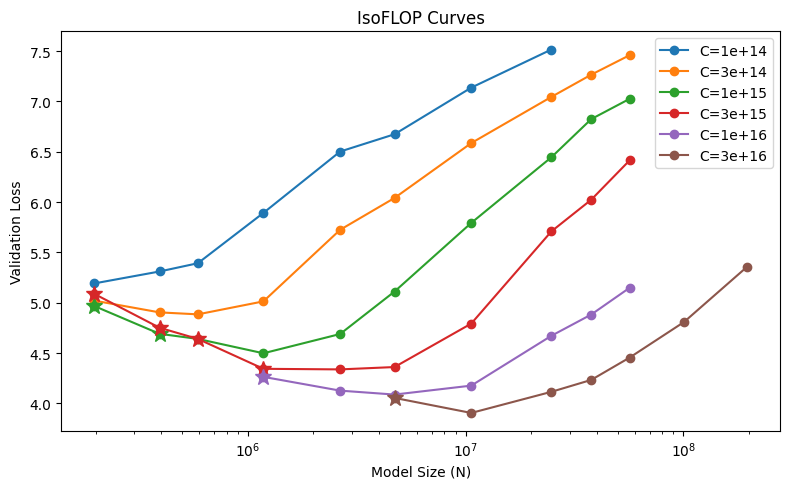

In [341]:
results = []
for (C, N), eid in experiment_ids.items():
    exp = get_experiment(eid)
    if exp.status.status_type == "completed" or exp.status.status_type == "running":
        results.append({"C": C, "N": N, "loss": exp.status.val_losses[-1], "failed": False})
    elif exp.status.status_type == "failed":
        results.append({"C": C, "N": N, "loss": exp.status.reason.partial_val_losses[-1], "failed": True})

budgets = sorted(set(r["C"] for r in results))

fig, ax = plt.subplots(figsize=(8, 5))

best_N, best_D = {}, {}
for i, C in enumerate(budgets):
    pts = sorted([r for r in results if r["C"] == C], key=lambda r: r["N"])

    # main curve
    ax.plot(
        [r["N"] for r in pts],
        [r["loss"] for r in pts],
        "o-",
        color=f"C{i}",
        label=f"C={C:.0e}",
    )

    failed_pts = [r for r in pts if r["failed"]]
    ax.plot(
        [r["N"] for r in failed_pts],
        [r["loss"] for r in failed_pts],
        "*",
        color=f"C{i}",
        markersize=12,
        linestyle="none",
    )

    best = min(pts, key=lambda r: r["loss"])
    best_N[C] = best["N"]
    best_D[C] = C / (6 * best["N"])

ax.set_xscale("log")
ax.set_xlabel("Model Size (N)")
ax.set_ylabel("Validation Loss")
ax.set_title("IsoFLOP Curves")
ax.legend()
plt.tight_layout()
plt.savefig("writeup/figures/isoflop_curves.png")
plt.show()

In [323]:
for (C, N), eid in experiment_ids.items():
    exp = get_experiment(eid)
    status = exp.status.status_type
    if status == "failed":
        print(f"C={C:.0e} N={N/1e6:.2f}M D={C/(6*N)/1e6:.1f}M status={status}")

C=1e+15 N=0.20M D=847.7M status=failed
C=1e+15 N=0.39M D=423.9M status=failed
C=3e+15 N=0.20M D=2543.1M status=failed
C=3e+15 N=0.39M D=1271.6M status=failed
C=3e+15 N=0.59M D=847.7M status=failed
C=3e+15 N=1.18M D=423.9M status=failed
C=1e+16 N=1.18M D=1412.9M status=failed
C=3e+16 N=4.72M D=1059.6M status=failed


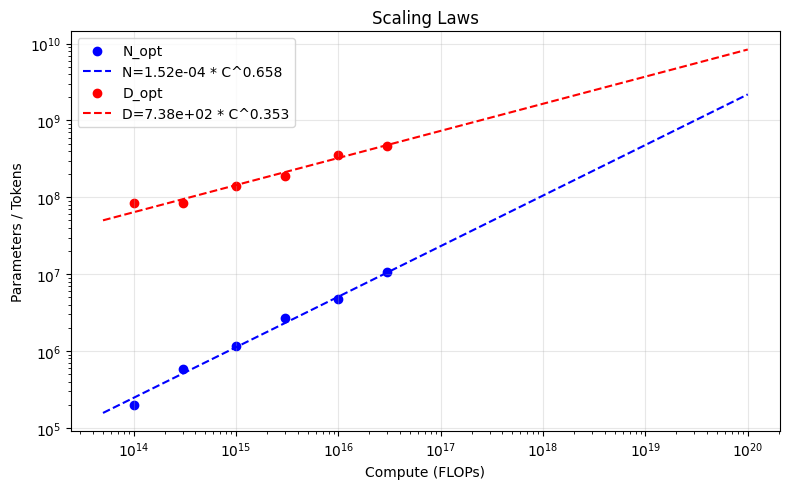

N_opt = 1.5246e-04 * C^0.6578
D_opt = 7.3783e+02 * C^0.3528


In [324]:
fig, ax = plt.subplots(figsize=(8, 5))

Cs = np.array(sorted(best_N.keys()))
N_opts = np.array([best_N[C] for C in Cs])
D_opts = np.array([best_D[C] for C in Cs])

pN, _ = curve_fit(lambda C, a, b: a * C**b, Cs, N_opts, p0=[1.0, 0.5], maxfev=5000)
pD, _ = curve_fit(lambda C, a, b: a * C**b, Cs, D_opts, p0=[1.0, 0.5], maxfev=5000)

C_fit = np.logspace(start=np.log10(Cs.min()/2), stop=20, num=100)
ax.scatter(Cs, N_opts, color="blue", label="N_opt")
ax.plot(C_fit, pN[0]*C_fit**pN[1], "--", color="blue", label=f"N={pN[0]:.2e} * C^{pN[1]:.3f}")

ax.scatter(Cs, D_opts, color="red", label="D_opt")
ax.plot(C_fit, pD[0]*C_fit**pD[1], "--", color="red", label=f"D={pD[0]:.2e} * C^{pD[1]:.3f}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Compute (FLOPs)")
ax.set_ylabel("Parameters / Tokens")
ax.set_title("Scaling Laws")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("writeup/figures/isoflop_scaling.png")
plt.show()

print(f"N_opt = {pN[0]:.4e} * C^{pN[1]:.4f}")
print(f"D_opt = {pD[0]:.4e} * C^{pD[1]:.4f}")

In [325]:
def get_n_scaling_law(C):
    return pN[0] * C**pN[1]

def get_d_scaling_law(C):
    return pD[0] * C**pD[1]

In [359]:
experiments = [e for e in list_experiments() if e.status.status_type == "completed"]

large_runs = []
for exp in experiments:
    cfg = exp.training_config.architecture_config
    N = 12 * cfg.num_hidden_layers * cfg.hidden_size**2
    D = exp.training_config.total_train_tokens
    runtime = exp.status.used_runtime_seconds
    flops = 6 * N * D
    throughput = flops / runtime
    
    # only use the runs where model is above 10M (models where MFU is not trash)
    if N > 50e6:
        large_runs.append(throughput)

print(f"Using {len(large_runs)} out of {len(experiments)} experiments")

avg_throughput = np.mean(large_runs)
print(f"Avg throughput: {avg_throughput:.2e} FLOPS")

budget_seconds = 48 * 3600  # 48 hours
total_flops = avg_throughput * budget_seconds
print(f"48 B200 hours = {total_flops:.2e} FLOPs")

# Predict optimal N and D
N_pred = get_n_scaling_law(total_flops)
D_pred = get_d_scaling_law(total_flops)
lr_pred = get_lr_opt(N_pred)

print("Predicted optimal:")
print(f"  N = {N_pred:.2e} ({N_pred/1e6:.1f}M)")
print(f"  D = {D_pred:.2e} ({D_pred/1e6:.0f}M)")
print(f"  LR = {lr_pred:.4e}")
print(f"  Check: 6*N*D = {6*N_pred*D_pred:.2e} vs budget {total_flops:.2e}")

Using 37 out of 152 experiments
Avg throughput: 2.06e+14 FLOPS
48 B200 hours = 3.56e+19 FLOPs
Predicted optimal:
  N = 1.11e+09 (1106.6M)
  D = 5.82e+09 (5820M)
  LR = 6.3798e-04
  Check: 6*N*D = 3.86e+19 vs budget 3.56e+19


In [355]:
D_pred = total_flops / (6 * N_pred)  # use all the budget
lr_pred = get_lr_opt(N_pred)

print(f"N = {N_pred:.2e} ({N_pred/1e6:.1f}M)")
print(f"D = {D_pred:.2e} ({D_pred/1e6:.0f}M)")
print(f"LR = {lr_pred:.4e}")
print(f"Check: 6*N*D = {6*N_pred*D_pred:.2e}")

N = 1.11e+09 (1106.6M)
D = 5.36e+09 (5361M)
LR = 6.3798e-04
Check: 6*N*D = 3.56e+19


In [363]:
for d in [512, 768, 1024, 1280, 1536, 2048]:
    heads = d // 64
    inter = ((d * 8 // 3 + 63) // 64) * 64
    layers = round(N_pred / (12 * d**2))
    actual_N = 12 * layers * d**2
    print(f"  d={d:5d} layers={layers:3d} heads={heads:2d} inter={inter:5d} N={actual_N/1e6:.1f}M")

  d=  512 layers=352 heads= 8 inter= 1408 N=1107.3M
  d=  768 layers=156 heads=12 inter= 2048 N=1104.2M
  d= 1024 layers= 88 heads=16 inter= 2752 N=1107.3M
  d= 1280 layers= 56 heads=20 inter= 3456 N=1101.0M
  d= 1536 layers= 39 heads=24 inter= 4096 N=1104.2M
  d= 2048 layers= 22 heads=32 inter= 5504 N=1107.3M


L_opt = 2.5755e+02 * C^(-0.1469) + 2.9332
Predicted loss at 3.56e+19 FLOPs: 3.2795
Predicted loss at 6ND = 3.86e+19 FLOPs: 3.2753


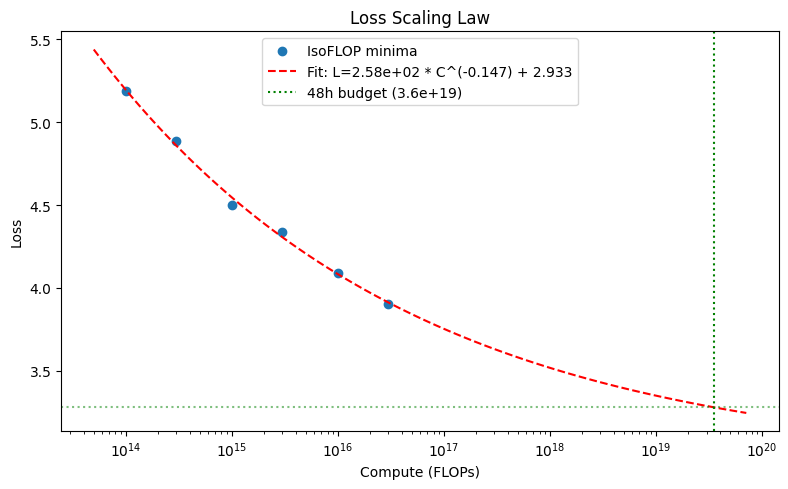

In [367]:
# From your isoflop results, extract best loss per budget
best_losses = {}
for C in budgets:
    pts = [r for r in results if r["C"] == C]
    best_losses[C] = min(r["loss"] for r in pts)

Cs = np.array(sorted(best_losses.keys()))
L_opts = np.array([best_losses[C] for C in Cs])

def loss_scaling(C, a, b, L_inf):
    return a * C**b + L_inf

popt, _ = curve_fit(loss_scaling, Cs, L_opts, p0=[100, -0.1, 1])
a, b, L_inf = popt
print(f"L_opt = {a:.4e} * C^({b:.4f}) + {L_inf:.4f}")

predicted_loss = loss_scaling(total_flops, *popt)
print(f"Predicted loss at {total_flops:.2e} FLOPs: {predicted_loss:.4f}")

flops_for_pred = 6 * N_pred * D_pred
predicted_loss_at_ND = loss_scaling(flops_for_pred, *popt)
print(f"Predicted loss at 6ND = {flops_for_pred:.2e} FLOPs: {predicted_loss_at_ND:.4f}")

# Plot
C_fit = np.logspace(np.log10(Cs.min()/2), np.log10(total_flops*2), 100)
plt.figure(figsize=(8, 5))
plt.scatter(Cs, L_opts, label="IsoFLOP minima")
plt.plot(C_fit, loss_scaling(C_fit, *popt), "r--", label=f"Fit: L={a:.2e} * C^({b:.3f}) + {L_inf:.3f}")
plt.axvline(total_flops, color="green", linestyle=":", label=f"48h budget ({total_flops:.1e})")
plt.axhline(predicted_loss, color="green", linestyle=":", alpha=0.5)
plt.xscale("log")
plt.xlabel("Compute (FLOPs)")
plt.ylabel("Loss")
plt.title("Loss Scaling Law")
plt.legend()
plt.tight_layout()
plt.savefig("writeup/figures/loss_scaling.png")
plt.show()

In [370]:
d = 2048
layers = 22

actual_N = 12 * layers * d**2
lr = get_lr_opt(actual_N)

D = D_pred
n_evals = 16
predicted_loss = loss_scaling(actual_N * D_pred * 6, *popt)

heads = d // 64
inter = ((d * 8 // 3 + 63) // 64) * 64
N = 12 * layers * d ** 2
tokens_per_batch = 512 * 128

# Make sure D is divisible by tokens_per_batch * n_evals
step_chunk = tokens_per_batch * n_evals
D = int(D // step_chunk) * step_chunk

print(f"Architecture: d={d}, layers={layers}, heads={heads}, inter={inter}")
print(f"N = {N/1e6:.1f}M non-embedding params")
print(f"D = {D/1e6:.0f}M tokens")
print(f"LR = {lr:.4e}")
print(f"Predicted loss = {predicted_loss:.4f}")
print(f"Check 6ND = {6*N*D:.2e}")

Architecture: d=2048, layers=22, heads=32, inter=5504
N = 1107.3M non-embedding params
D = 5820M tokens
LR = 6.3783e-04
Predicted loss = 3.2753
Check 6ND = 3.87e+19


In [371]:
config = TrainingConfig(
    architecture_config=BasicTransformerConfig(
        attention_bias=False,
        head_dim=64,
        hidden_size=d,
        intermediate_size=inter,
        num_attention_heads=heads,
        num_hidden_layers=layers,
        num_key_value_heads=heads,
        rms_norm_eps=1e-6,
        rope_theta=1_000_000,
        tie_word_embeddings=False,
        dtype="bfloat16",
        vocab_size=32_000,
    ),
    optimizer_config=AdamWConfig(
        lr_scheduler=WarmupCosineDecay(
            peak_value=lr,
            final_lr_frac=0.1,
            warmup_frac=0.05,
            init_value=0.0,
        ),
        weight_decay=1e-2,
        beta1=0.9,
        beta2=0.95,
        eps=1e-8,
        eps_root=1e-8,
        grad_clip_norm=1.0,
    ),
    train_batch_size=128,
    val_batch_size=32,
    n_evals=n_evals,
    total_train_tokens=D,
    max_runtime_seconds=48 * 3600,
    model_seed=0,
)

rich.print(save_final_submission(config, predicted_loss))

FinalSubmissionResponse(
    training_config=TrainingConfig(
        architecture_config=BasicTransformerConfig(
            attention_bias=False,
            head_dim=64,
            hidden_size=2048,
            intermediate_size=5504,
            num_attention_heads=32,
            num_hidden_layers=22,
            num_key_value_heads=32,
            rms_norm_eps=1e-06,
            rope_theta=1000000,
            tie_word_embeddings=False,
            dtype='bfloat16',
            vocab_size=32000
        ),
        optimizer_config=AdamWConfig(
            lr_scheduler=WarmupCosineDecay(
                peak_value=0.0006378328491960411,
                final_lr_frac=0.1,
                warmup_frac=0.05,
                init_value=0.0
            ),
            weight_decay=0.01,
            beta1=0.9,
            beta2=0.95,
            eps=1e-08,
            eps_root=1e-08,
            grad_clip_norm=1.0
        ),
        train_batch_size=128,
        val_batch_size=32,
        n_evals=16,
        total_train_tokens=5819596800,
        max_runtime_seconds=172800.0,
        model_seed=0
    ),
    predicted_final_loss=3.2752684193921002,
    submitted_at=datetime.datetime(2026, 5, 7, 10, 3, 59, 882591, tzinfo=TzInfo(0))
)